In [ ]:
!pip install kagglehub --quiet

import os

import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras

from keras import layers

# to keep check on training
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

print("GPU available:", tf.config.list_physical_devices('GPU'))

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.19.0
GPU available: []
Num GPUs Available: 0


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/crop_disease_mobilenet/'

CHECKPOINT_PATH = DRIVE_PATH + 'best_model.keras'

HISTORY_PATH = DRIVE_PATH + 'history.npy'

os.makedirs(DRIVE_PATH, exist_ok=True)

print("Drive mounted")
print("Files will save to:", DRIVE_PATH)

Mounted at /content/drive
Drive mounted ✓
Files will save to: /content/drive/MyDrive/crop_disease_mobilenet/


In [ ]:
import kagglehub

path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("dataset path : ",path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
dataset path :  /kaggle/input/plantvillage-dataset


In [ ]:
os.getcwd()

'/content'

In [ ]:
os.listdir()

['.config', 'drive', 'sample_data']

In [ ]:
os.chdir('/kaggle/input/plantvillage-dataset/plantvillage dataset')

os.getcwd()

'/kaggle/input/plantvillage-dataset/plantvillage dataset'

In [ ]:
os.listdir()

['segmented', 'grayscale', 'color']

In [ ]:
# using only color

# color_dataset_path = '/kaggle/input/plantvillage-dataset/plantvillage dataset/color'
color_dataset_path = os.path.join(os.getcwd(),'color')

color_dataset_path

'/kaggle/input/plantvillage-dataset/plantvillage dataset/color'

In [ ]:
class_names = sorted(os.listdir(color_dataset_path))
num_classes = len(class_names)

print("number of classes : ", num_classes)
print("class names : ")
class_names[::3]

number of classes :  38
class names : 


['Apple___Apple_scab',
 'Apple___healthy',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Grape___Esca_(Black_Measles)',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Pepper,_bell___Bacterial_spot',
 'Potato___Late_blight',
 'Soybean___healthy',
 'Strawberry___healthy',
 'Tomato___Late_blight',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Tomato_mosaic_virus']

### Loading data

In [ ]:
IMG_SIZE = 128

BATCH_SIZE = 16

# load images from the color folder
# validation_split = 80% training, 20% validation
train_ds = tf.keras.utils.image_dataset_from_directory(
    color_dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    color_dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

num_classes = len(class_names)

print(f"Image size        : {IMG_SIZE}×{IMG_SIZE}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Training batches  : {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Total classes     : {num_classes}")

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Image size        : 128×128
Batch size        : 16
Training batches  : 2716
Validation batches: 679
Total classes     : 38


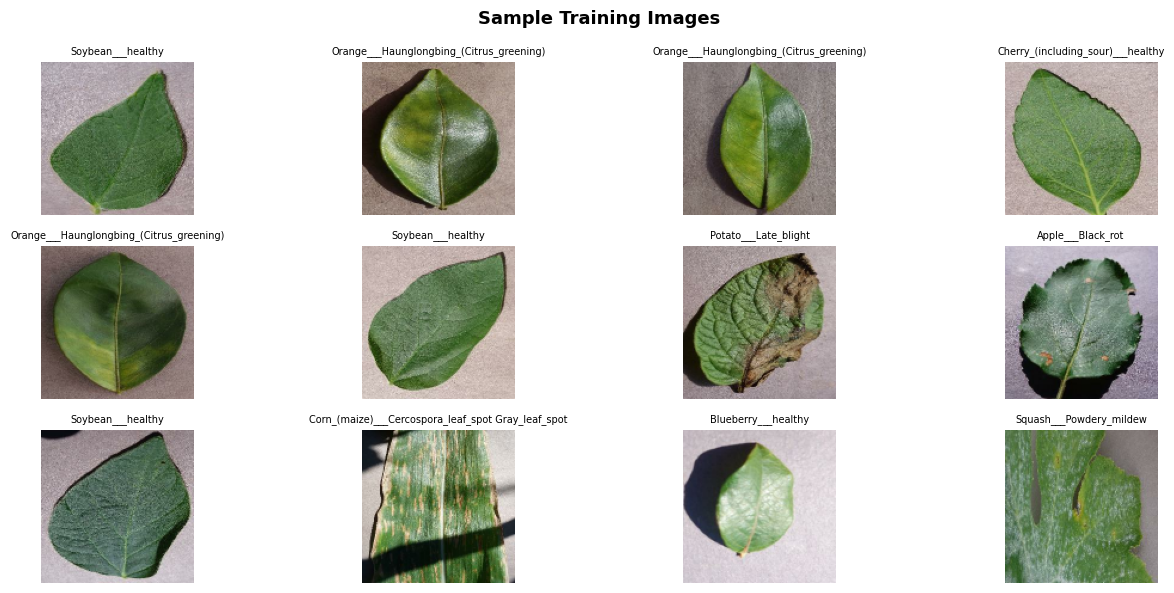

In [ ]:
plt.figure(figsize=(14, 6))

for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]], fontsize=7)
        plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

# Sequential groups multiple augmentation layers
# activate during training, not validation
augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomTranslation(0.1, 0.1),

    layers.RandomContrast(0.2),

], name="augmentation")

# MobileNetV2 was trained with pixels in range [-1.0, 1.0]
def preprocess(image, label):
    image = tf.cast(image, tf.float32)

    # MobileNetV2's specific normalization: (pixel/127.5) - 1
    # converts pixel range from [0, 255] to [-1.0, 1.0]
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

train_ds = (
    train_ds
    .map(lambda x, y: (augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)

    .map(preprocess, num_parallel_calls=AUTOTUNE)

    # load next batch while GPU trains on current batch
    .prefetch(AUTOTUNE)
)

# validation — no augmentation
val_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("Augmentation & preprocessing pipeline ready")

Augmentation & preprocessing pipeline ready ✓


In [ ]:
def build_mobilenet_model(num_classes, img_size):

    # loads MobileNetV2 architecture WITH pretrained ImageNet weights
    # input_shape - 128x128 RGB
    # include_top = False add our own 38-class head
    base_model = keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )

    # freeze ALL layers in base model
    # use pretrained weights on new classes
    base_model.trainable = False

    inputs = keras.Input(shape=(img_size, img_size, 3))

    # BatchNorm layers in inference mode
    x = base_model(inputs, training=False)

    # converts the 4×4×1280 feature map - 1280-element vector
    x = layers.GlobalAveragePooling2D()(x)

    # relu activation: adds non-linearity
    x = layers.Dense(512, activation='relu')(x)

    # forces network to learn redundant representations
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, activation='relu')(x)

    x = layers.Dropout(0.2)(x)

    # softmax converts raw scores into probabilities that sum to 1.0
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    # we need base_model for in Phase 2
    return model, base_model

# build the model
model, base_model = build_mobilenet_model(num_classes, IMG_SIZE)

# correct loss for integer labels (0-37)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,054,950 (11.65 MB)

 Trainable params: 796,966 (3.04 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
if os.path.exists(CHECKPOINT_PATH):

    print("Checkpoint found on Drive! Loading...")

    model = tf.keras.models.load_model(CHECKPOINT_PATH)

    base_model = model.layers[1]

    print("Model loaded from Drive")
    print(f"Base model trainable layers: "
          f"{sum([1 for l in base_model.layers if l.trainable])}")

else:
    print("No checkpoint found — will train from scratch")

model.summary()

Checkpoint found on Drive! Loading...
Model loaded from Drive ✓
Base model trainable layers: 1


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,648,884 (17.73 MB)

 Trainable params: 796,966 (3.04 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 1,593,934 (6.08 MB)

In [ ]:
callbacks = [

    EarlyStopping(
        monitor='val_loss',

        patience=5,

        restore_best_weights=True,

        verbose=1
    ),

    ModelCheckpoint(

        CHECKPOINT_PATH,

        monitor='val_loss',

        save_best_only=True,

        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',


        factor=0.5,

        patience=3,

        min_lr=1e-7,

        verbose=1
    )
]

print("Callbacks configured")

Callbacks configured ✓


In [ ]:
if os.path.exists(HISTORY_PATH):

    # load the saved history dictionary

    old_history = np.load(HISTORY_PATH, allow_pickle=True).item()

    # len of loss list = number of completed epochs
    START_EPOCH = len(old_history['loss'])
    print(f"Resuming from epoch {START_EPOCH}")

else:
    START_EPOCH = 0
    print("Starting Phase 1 from epoch 0")


PHASE1_EPOCHS = 10

history_phase1 = model.fit(
    train_ds,

    initial_epoch=START_EPOCH,

    epochs=PHASE1_EPOCHS,

    validation_data=val_ds,

    callbacks=callbacks
)

if os.path.exists(HISTORY_PATH):
    old_h = np.load(HISTORY_PATH, allow_pickle=True).item()
    for key in history_phase1.history:
        old_h[key] = old_h[key] + history_phase1.history[key]
    np.save(HISTORY_PATH, old_h)
else:
    np.save(HISTORY_PATH, history_phase1.history)


full_history = np.load(HISTORY_PATH, allow_pickle=True).item()

print("Available keys:", full_history.keys())

val_acc = full_history.get('val_accuracy') or full_history.get('val_acc')

if val_acc:
    print(f"\nPhase 1 complete!")
    print(f"Best val accuracy : {max(val_acc):.4f}")
else:
    print("\nval_accuracy not found. Available keys:", full_history.keys())

Starting Phase 1 from epoch 0
Epoch 1/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6893 - loss: 1.1007
Epoch 1: val_loss improved from None to 0.45068, saving model to /content/drive/MyDrive/crop_disease_mobilenet/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/crop_disease_mobilenet/best_model.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 303s 108ms/step - accuracy: 0.7739 - loss: 0.7558 - val_accuracy: 0.8394 - val_loss: 0.4507 - learning_rate: 0.0010
Epoch 2/10
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8418 - loss: 0.5084
Epoch 2: val_loss did not improve from 0.45068
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 241s 89ms/step - accuracy: 0.8453 - loss: 0.4967 - val_accuracy: 0.8348 - val_loss: 0.4643 - learning_rate: 0.0010
Epoch 3/10
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8581 - loss: 0.4617
Epoch 3: val_loss did not improve from 0.45068
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 265s 90ms/step - accuracy: 0.8616 - loss: 0.4506 - val_acc

In [ ]:
print("Starting Phase 2 — Fine Tuning...")

PHASE1_EPOCHS = 10

model = tf.keras.models.load_model(CHECKPOINT_PATH)
base_model = model.layers[1]

# Unfreeze top 30 layers of base
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum([1 for l in base_model.layers if l.trainable])
print(f"Trainable base layers : {trainable_count} / {len(base_model.layers)}")

PHASE2_EPOCHS = 20
PHASE2_CHECKPOINT = DRIVE_PATH + 'best_model_phase2.keras'
PHASE2_HISTORY    = DRIVE_PATH + 'history_phase2.npy'

if os.path.exists(PHASE2_CHECKPOINT):
    print("Phase 2 checkpoint found — resuming...")
    model = tf.keras.models.load_model(PHASE2_CHECKPOINT)
    base_model = model.layers[1]

  # continue from prev run
    old_p2 = np.load(PHASE2_HISTORY, allow_pickle=True).item()
    epochs_done = len(old_p2['loss'])
    START_EPOCH = PHASE1_EPOCHS + epochs_done # e.g. 10 + 7 = 17
    print(f"Resuming Phase 2 from epoch {START_EPOCH}")
else:
    START_EPOCH = PHASE1_EPOCHS
    print(f"Starting Phase 2 from epoch {START_EPOCH}")

Starting Phase 2 — Fine Tuning...
Trainable base layers : 30 / 154
Starting Phase 2 from epoch 10


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        PHASE2_CHECKPOINT,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
history_phase2 = model.fit(
    train_ds,
    epochs=PHASE1_EPOCHS + PHASE2_EPOCHS,
    initial_epoch=START_EPOCH,
    validation_data=val_ds,
    callbacks=callbacks_phase2
)

if os.path.exists(PHASE2_HISTORY):
    old_p2 = np.load(PHASE2_HISTORY, allow_pickle=True).item()
    for key in history_phase2.history:
        old_p2[key] = old_p2[key] + history_phase2.history[key]
    np.save(PHASE2_HISTORY, old_p2)
else:
    np.save(PHASE2_HISTORY, history_phase2.history)

full_p2 = np.load(PHASE2_HISTORY, allow_pickle=True).item()
val_acc = full_p2.get('val_accuracy') or full_p2.get('val_acc')

print(f"\nPhase 2 complete!")
if val_acc:
    print(f"Best val accuracy : {max(val_acc):.4f}")
else:
    print("val_accuracy not found:", full_p2.keys())

Epoch 11/30
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6681 - loss: 1.5150
Epoch 11: val_loss improved from None to 0.43033, saving model to /content/drive/MyDrive/crop_disease_mobilenet/best_model_phase2.keras

Epoch 11: finished saving model to /content/drive/MyDrive/crop_disease_mobilenet/best_model_phase2.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 367s 125ms/step - accuracy: 0.7524 - loss: 0.9952 - val_accuracy: 0.8550 - val_loss: 0.4303 - learning_rate: 1.0000e-05
Epoch 12/30
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8414 - loss: 0.5553
Epoch 12: val_loss improved from 0.43033 to 0.36587, saving model to /content/drive/MyDrive/crop_disease_mobilenet/best_model_phase2.keras

Epoch 12: finished saving model to /content/drive/MyDrive/crop_disease_mobilenet/best_model_phase2.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 250s 92ms/step - accuracy: 0.8505 - loss: 0.5202 - val_accuracy: 0.8786 - val_loss: 0.3659 - learning_rate: 1.0000e-05
Epoch 13/30
2714/2716 ━━━━━━━━━

In [ ]:
import tensorflow as tf

DRIVE_PATH = '/content/drive/MyDrive/crop_disease_mobilenet/'
FINAL_PATH = DRIVE_PATH + 'best_model_phase2.keras'

model = tf.keras.models.load_model(FINAL_PATH)
print("Model loaded")
model.summary()

Model loaded


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701,684 (29.38 MB)

 Trainable params: 2,323,366 (8.86 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 4,646,734 (17.73 MB)